# Perturbation LOO Evaluation

Evaluates the perturbation model on a held-out cell type in the CRC region.
For each cell type we compute the top-100 pseudobulk logFC genes (CRC vs REF),
perturb REF cells' spatial context accordingly, and measure how well the
predicted expression shift matches the real CRC expression.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import matplotlib.pyplot as plt

import cellina_graph
from cellina_graph import CellinaModel
from cellina_graph._spatial_utils import spatial_neighbors

from perturb_utils import load_crc_slide, split_indices, compute_cf_logfc

plt.rcParams['figure.dpi'] = 75
print(cellina_graph.__version__)

0.2.0


In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id         = 232
labels_key       = 'coarse_type'
domains_key      = 'typ'
holdout_celltype = 'T_cell'
top_n_perturb    = 100   # genes used to perturb spatial context
top_n            = 100   # genes used to evaluate metrics
min_cells        = 50    # minimum cells per domain per cell type to evaluate
batch_size       = 512
base_path        = 'results/perturb_loo'
save_path        = f'{base_path}/trained/crc_{slide_id}_{holdout_celltype}'
library_size     = 1e4

## 1. Data Loading

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
print(adata)

AnnData object with n_obs × n_vars = 111989 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

## 2. Holdout Split

Mark `holdout_celltype` cells in CRC regions as test (holdout). These cells are used
**only for evaluation** — their ground-truth CRC expression is the target we compare against.

In [4]:
train_idx, val_idx, test_idx = split_indices(
    adata, holdout_celltype=holdout_celltype,
    labels_key=labels_key, domains_key=domains_key,
)

print(f"train: {len(train_idx):,}  val: {len(val_idx):,}  test (holdout): {len(test_idx):,}")
print(f"Holdout cells: {adata.obs['is_holdout'].sum()} {holdout_celltype} in CRC region")

train: 98,277  val: 10,919  test (holdout): 2,793
Holdout cells: 2793 T_cell in CRC region


## 3. Spatial Graph & Features

In [5]:
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=50, standardize=False)

In [6]:
adata.obsm['spatial'][:,0].min(), adata.obsm['spatial'][:,0].max()

(71913, 110095)

In [7]:
adata.obsm['spatial'][:,1].min(), adata.obsm['spatial'][:,1].max()

(63106, 109862)

## 4. Model Training

In [ ]:
CellinaModel.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_connectivities_key='spatial_connectivities',
)

model = CellinaModel(
    adata,
    n_latent=20,
    convolution_type='gat',
    n_layers=3,
    classifier_lambda=1,
    discriminator_lambda=1,
    link_prediction_weight=0.5,
    condition_on_intrinsic=False,
)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [9]:
model.train(
    max_epochs=30,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_monitor='vae_loss_validation',
    train_size=0.9,
    validation_size=0.1,
    plan_kwargs={
        'lr': 1e-3,
        'weight_decay': 0.0001,
        'normalize_losses': True,
    },
    datasplitter_kwargs={"external_indexing": [train_idx, val_idx, test_idx]},
    enable_checkpointing=True,
    batch_size=batch_size,
    devices=[1],
)

INFO: GPU available: True (cuda), used: True
2026-04-01 18:35:45 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-04-01 18:35:45 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-04-01 18:35:45 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-04-01 18:35:45 | [INFO] You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.o

Training:   0%|          | 0/30 [00:00<?, ?it/s]

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 23203. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 23103. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 23763. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py

In [10]:
model.save(save_path, overwrite=True)

<Axes: xlabel='epoch'>

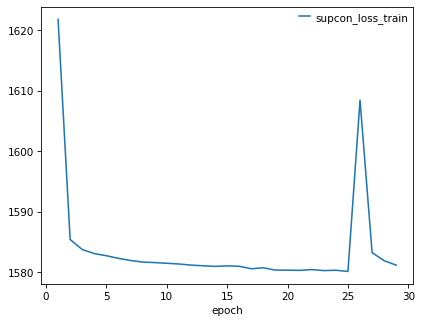

In [11]:
model.history_['supcon_loss_train'].plot()

<Axes: xlabel='epoch'>

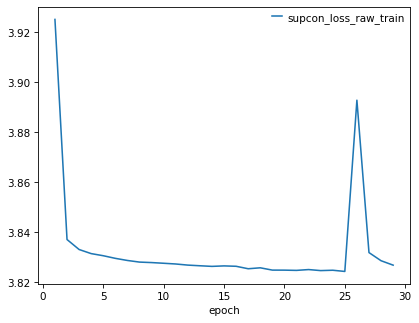

In [19]:
model.history_['supcon_loss_raw_train'].plot()

## 5. Counterfactual Neighbour Pool

In [12]:
# Infer domain labels
domains = adata.obs[domains_key].astype(str).unique()
ref_label = next(d for d in domains if 'REF' in d)
crc_label = next(d for d in domains if 'CRC' in d)

# Cell types present in both domains
cell_types = [
    ct for ct in adata.obs[labels_key].cat.categories
    if ((adata.obs[domains_key] == ref_label) & (adata.obs[labels_key] == ct)).any()
    and ((adata.obs[domains_key] == crc_label) & (adata.obs[labels_key] == ct)).any()
]

# All CRC region cell indices — used as the counterfactual neighbour pool
crc_all_idx = np.where(adata.obs[domains_key].astype(str).str.contains('CRC'))[0]

print(f"REF: {ref_label},  CRC: {crc_label}")
print(f"Cell types in both domains: {cell_types}")
print(f"CRC neighbour pool: {len(crc_all_idx):,} cells")

REF: 232_REF,  CRC: 232_CRC
Cell types in both domains: ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']
CRC neighbour pool: 82,258 cells


## 6. Expression Retrieval & Metrics

For each cell type, REF cells are given CRC-region cells as counterfactual neighbours
(graph edges are rewired). The model predicts expression under this altered spatial context.

In [13]:
rows = []
logfcs = {}

def _normalize_total(arr, target_sum=library_size):
    return arr / arr.sum(axis=1, keepdims=True) * target_sum

for ct in sorted(cell_types):
    ref_mask = (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == ref_label)
    crc_mask = (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == crc_label)

    # For the holdout cell type, evaluate only on holdout cells
    if ct == holdout_celltype:
        crc_mask = crc_mask & adata.obs['is_holdout']

    ref_idx = np.where(ref_mask.values)[0]
    crc_idx = np.where(crc_mask.values)[0]

    if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
        print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
        continue

    print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")

    # Raw normalised expression
    ref_arr = adata[ref_idx].layers['counts']
    ref_expr = ref_arr.toarray() if hasattr(ref_arr, 'toarray') else np.asarray(ref_arr)
    ref_expr = _normalize_total(ref_expr, target_sum=library_size)

    crc_arr = adata[crc_idx].layers['counts']
    cf_expr = crc_arr.toarray() if hasattr(crc_arr, 'toarray') else np.asarray(crc_arr)
    cf_expr = _normalize_total(cf_expr, target_sum=library_size)

    # Counterfactual expression: rewire REF cells to use CRC neighbours
    pert_expr = model.get_counterfactual_expression(
        indices=ref_idx,
        neighbour_indices=crc_all_idx,
        batch_size=batch_size,
        n_neighbors_per_seed=30,
        library_size=library_size
    )

    stats = compute_cf_logfc(
        ref_expr, pert_expr, cf_expr,
        top_n=top_n,
        gene_names=adata.var_names.tolist(),
    )

    rows.append(dict(
        cell_type=ct,
        holdout=(ct == holdout_celltype),
        n_ref=len(ref_idx),
        n_crc=len(crc_idx),
        pearson_r=stats['pearson_r'],
        spearman_r=stats['spearman_r'],
        precision=stats['precision'],
        mixing_index=stats['mixing_index'],
    ))
    logfcs[ct] = stats

summary_df = pd.DataFrame(rows).sort_values('pearson_r', ascending=False).reset_index(drop=True)
summary_df

  Endothelial: ref=1772, crc=4994


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Epithelial: ref=12646, crc=37319


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Fibroblast: ref=2881, crc=20695


...

  Smooth_muscle: ref=1528, crc=4157


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  T_cell: ref=1484, crc=2793


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


,cell_type,holdout,n_ref,n_crc,pearson_r,spearman_r,precision,mixing_index
0,Epithelial,False,12646,37319,0.966862,0.849061,0.75,0.791977
1,Myeloid,False,1033,5035,0.943476,0.864146,0.47,0.864548
2,Endothelial,False,1772,4994,0.938667,0.889349,0.40,0.926876
3,Smooth_muscle,False,1528,4157,0.929780,0.811617,0.40,0.782295
4,Fibroblast,False,2881,20695,0.891516,0.849025,0.43,0.707417
5,T_cell,True,1484,2793,0.868990,0.795740,0.29,0.993913
6,Plasma_cell,False,8387,7265,0.836950,0.680384,0.33,0.802411


In [14]:
# cell_type	holdout	n_ref	n_crc	pearson_r	spearman_r	precision	mixing_index
# 0	Epithelial	False	12646	37319	0.979292	0.903750	0.72	0.803475
# 1	Fibroblast	False	2881	20695	0.944322	0.910603	0.51	0.711283
# 2	Endothelial	False	1772	4994	0.935378	0.885113	0.41	0.796520
# 3	Smooth_muscle	False	1528	4157	0.919488	0.861974	0.36	0.786625
# 4	Myeloid	False	1033	5035	0.913512	0.827591	0.34	0.857597
# 5	Plasma_cell	False	8387	7265	0.841154	0.711791	0.32	0.790135
# 6	T_cell	True	1484	2793	0.738771	0.733093	0.20	0.926602

## 7. Visualization: logFC Scatter Plots

In [15]:
assert adata.obs.loc[adata.obs.index[model.test_indices_], labels_key].unique() == [holdout_celltype]

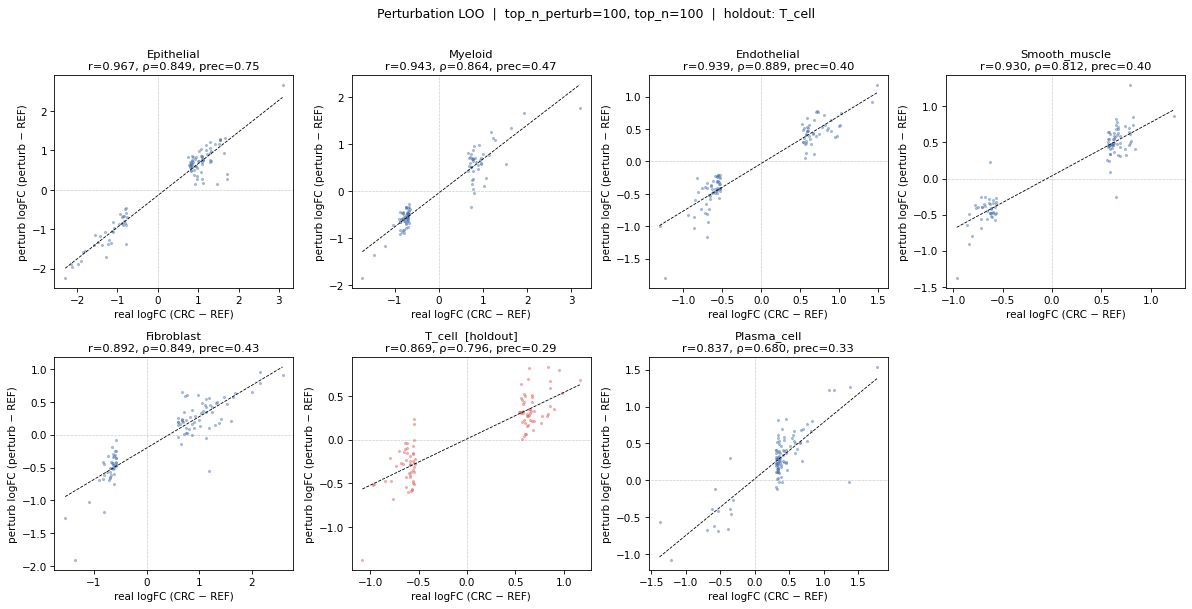

In [16]:
ncols = 4
nrows = (len(summary_df) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, row in summary_df.iterrows():
    ct  = row['cell_type']
    ax  = axes[i]
    real = logfcs[ct]['real_logfc']
    pred = logfcs[ct]['pred_logfc']
    mask = logfcs[ct]['top_n_mask']
    if mask is not None:
        real, pred = real[mask], pred[mask]

    color = '#e05c5c' if row['holdout'] else '#4C72B0'
    ax.scatter(real, pred, s=4, alpha=0.4, color=color)

    m, b = np.polyfit(real, pred, 1)
    x_lo, x_hi = real.min(), real.max()
    ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], color='k', lw=0.8, ls='--')
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')

    title = f"{ct}{'  [holdout]' if row['holdout'] else ''}"
    ax.set_title(
        f"{title}\nr={row['pearson_r']:.3f}, ρ={row['spearman_r']:.3f}, prec={row['precision']:.2f}",
        fontsize=11,
    )
    ax.set_xlabel('real logFC (CRC − REF)', fontsize=10)
    ax.set_ylabel('perturb logFC (perturb − REF)', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Perturbation LOO  |  top_n_perturb={top_n_perturb}, top_n={top_n}  |  holdout: {holdout_celltype}", y=1.01)
plt.tight_layout()
plt.show()

In [17]:
model.get_marginal_ll(adata, indices=model.test_indices_, reduce='mean')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


-359.8286118940874

In [18]:
# -342.7559647993608